# Milestone 4 — Final Model (BLIP-2)
**Configuration:** BLIP-2 (Salesforce/blip2-opt-2.7b) + LoRA + 10 Epochs + Cosine LR Scheduler

**Batch Size:** 8 | **Decoding:** Beam Search (width 5) | **Fine-Tuning:** LoRA via PEFT


## 1 — Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q transformers datasets accelerate peft evaluate nltk rouge_score pycocoevalcap matplotlib pandas seaborn bitsandbytes


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.1 MB/s eta 0:00:00


In [3]:
import os, json, re, glob, zipfile, random, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
from collections import defaultdict
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings('ignore')

# ── Device setup ──
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Using device: CUDA ({torch.cuda.get_device_name(0)})')
else:
    try:
        import torch_xla
        import torch_xla.core.xla_model as xm
        DEVICE = torch_xla.device()
        print('Using device: TPU')
    except Exception:
        DEVICE = torch.device('cpu')
        print('Using device: CPU')

print(f'Device: {DEVICE}')

Using device: CUDA (NVIDIA A100-SXM4-80GB)
Device: cuda


In [4]:
# ── Hugging Face login ──
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN, add_to_git_credential=True)
print('Logged in to Hugging Face')

Logged in to Hugging Face


## 2 — Load Dataset (10k COCO Training Images)

In [5]:
from datasets import load_dataset

# ── Extract images ──
ZIP_3K_PATH = '/content/drive/MyDrive/NEU/IE 7615 Deep Learning/Generative Project/Milestone 4/train_images_3k.zip'
ZIP_7K_PATH = '/content/drive/MyDrive/NEU/IE 7615 Deep Learning/Generative Project/Milestone 4/train_images_7k.zip'
EXTRACT_DIR = '/content/coco_train_images'
os.makedirs(EXTRACT_DIR, exist_ok=True)

for zip_path in [ZIP_3K_PATH, ZIP_7K_PATH]:
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(EXTRACT_DIR)

all_image_files = sorted(glob.glob(os.path.join(EXTRACT_DIR, '**', '*.*'), recursive=True))
print(f'Found {len(all_image_files)} image files in {EXTRACT_DIR}')
filename_to_path = {os.path.basename(f): f for f in all_image_files}
cocoid_to_path = {
    int(re.findall(r'(\d+)', os.path.splitext(f)[0])[-1]): f
    for f in all_image_files if re.findall(r'(\d+)', f)
}

coco_ds = load_dataset('yerevann/coco-karpathy', split='train')

def has_local_image(ex):
    return ex.get('filename') in filename_to_path or ex.get('cocoid') in cocoid_to_path

coco_local = coco_ds.filter(has_local_image, num_proc=4)
print(f'Number of samples in coco_local (with local images): {len(coco_local)}')

TRAIN_SIZE = min(10000, len(coco_local))
random.seed(42)
train_subset = coco_local.select(random.sample(range(len(coco_local)), TRAIN_SIZE))
eval_samples = coco_local.select(random.sample(range(len(coco_local)), min(50, len(coco_local))))

print(f'TRAIN_SIZE: {TRAIN_SIZE}')
print(f'Number of samples in train_subset: {len(train_subset)}')
print(f'Number of samples for evaluation: {len(eval_samples)}')

def load_image(sample):
    if sample.get('filename') in filename_to_path:
        return Image.open(filename_to_path[sample['filename']]).convert('RGB')
    return Image.open(cocoid_to_path[sample['cocoid']]).convert('RGB')

Found 10000 image files in /content/coco_train_images


README.md:   0%|          | 0.00/246 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/17.0M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating restval split:   0%|          | 0/30504 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/82783 [00:00<?, ? examples/s]

Number of samples in coco_local (with local images): 1368
TRAIN_SIZE: 1368
Number of samples in train_subset: 1368
Number of samples for evaluation: 50


## 3 — Load BLIP-2 Model


In [6]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

MODEL_NAME = 'Salesforce/blip2-opt-2.7b'

processor = Blip2Processor.from_pretrained(MODEL_NAME)
model = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16
).to(DEVICE)
model.eval()

print(f'BLIP-2 loaded on {DEVICE}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded on cuda
Parameters: 3,744,761,856


## 4 — Baseline Evaluation (Before Fine-Tuning)

In [19]:
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider
from nltk.translate.meteor_score import meteor_score as nltk_meteor
import nltk

def compute_metrics(predictions, references):
    gts = {i: refs for i, refs in enumerate(references)}
    res = {i: [pred] for i, pred in enumerate(predictions)}

    scorers = [
        (Bleu(4), ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']),
        (Rouge(), 'ROUGE-L'),
        (Cider(), 'CIDEr'),
    ]

    scores = {}
    for scorer, method in scorers:
        score, _ = scorer.compute_score(gts, res)
        if isinstance(method, list):
            for m, s in zip(method, score):
                scores[m] = s
        else:
            scores[method] = score

    # METEOR via NLTK (avoids Java subprocess bug)
    meteor_scores = []
    for i in range(len(predictions)):
        ref_tokens = [nltk.word_tokenize(r) for r in references[i]]
        pred_tokens = nltk.word_tokenize(predictions[i])
        meteor_scores.append(nltk_meteor(ref_tokens, pred_tokens))
    scores['METEOR'] = np.mean(meteor_scores)

    return scores

print('Metrics functions ready.')

Metrics functions ready.


In [20]:
# ── Caption generation function (BLIP-2) ──
def generate_captions(model, processor, samples, strategy='beam',
                      beam_width=5, temperature=1.0, top_p=0.9,
                      max_length=40, device=DEVICE):
    """
    Generate captions for a list of dataset samples using BLIP-2.
    strategy: 'greedy', 'beam', 'sampling', 'top_p'
    """
    model.eval()
    captions = []

    for sample in tqdm(samples, desc=f'Generating ({strategy})'):
        img = load_image(sample)
        inputs = processor(images=img, return_tensors='pt').to(device, torch.bfloat16)

        with torch.no_grad():
            if strategy == 'greedy':
                out = model.generate(
                    **inputs,
                    max_new_tokens=max_length,
                    num_beams=1,
                    do_sample=False
                )
            elif strategy == 'beam':
                out = model.generate(
                    **inputs,
                    max_new_tokens=max_length,
                    num_beams=beam_width,
                    do_sample=False
                )
            elif strategy == 'sampling':
                out = model.generate(
                    **inputs,
                    max_new_tokens=max_length,
                    do_sample=True,
                    temperature=temperature,
                    top_k=50
                )
            elif strategy == 'top_p':
                out = model.generate(
                    **inputs,
                    max_new_tokens=max_length,
                    do_sample=True,
                    temperature=temperature,
                    top_p=top_p,
                    top_k=0
                )

        caption = processor.decode(out[0], skip_special_tokens=True).strip()
        captions.append(caption)

    return captions

print('Caption generation function ready.')


Caption generation function ready.


In [21]:
# ── Collect references ──
def get_references(samples):
    """Get reference captions for evaluation samples."""
    refs = []
    for sample in samples:
        sentences = sample.get('sentences', [])
        if isinstance(sentences, list) and len(sentences) > 0:
            if isinstance(sentences[0], dict):
                refs.append([s['raw'] for s in sentences])
            else:
                refs.append(sentences)
        elif 'caption' in sample:
            cap = sample['caption']
            refs.append(cap if isinstance(cap, list) else [cap])
        else:
            refs.append([''])
    return refs

references = get_references(eval_samples)
print(f'References collected for {len(references)} samples')
print(f'Sample reference: {references[0][0][:80]}...' if references[0][0] else 'Empty')

References collected for 50 samples
Sample reference: a close up of a cat laying on grass near a shoe...


In [22]:
# ── Baseline evaluation (before LoRA) ──
print('Running baseline evaluation (before fine-tuning)...')
baseline_captions = generate_captions(model, processor, eval_samples,
                                       strategy='beam', beam_width=5)
baseline_scores = compute_metrics(baseline_captions, references)

print('\n=== Baseline Scores (Before Fine-Tuning) ===')
for k, v in baseline_scores.items():
    print(f'  {k}: {v:.4f}')

Running baseline evaluation (before fine-tuning)...


Generating (beam):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 469, 'reflen': 476, 'guess': [469, 419, 369, 319], 'correct': [151, 26, 6, 1]}
ratio: 0.9852941176449889

=== Baseline Scores (Before Fine-Tuning) ===
  BLEU-1: 0.3172
  BLEU-2: 0.1393
  BLEU-3: 0.0677
  BLEU-4: 0.0313
  ROUGE-L: 0.2272
  CIDEr: 0.0422
  METEOR: 0.1769


## 5 — Apply LoRA Adapters

In [23]:
from peft import LoraConfig, get_peft_model, TaskType

# ── LoRA Configuration for BLIP-2 (OPT decoder) ──
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias='none',
    target_modules=['q_proj', 'v_proj', 'k_proj', 'out_proj',
                    'fc1', 'fc2'],
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
model.to(DEVICE)

print('\nLoRA adapters applied to BLIP-2.')


trainable params: 33,017,856 || all params: 3,777,779,712 || trainable%: 0.8740

LoRA adapters applied to BLIP-2.


## 6 — Training Dataset & DataLoader

In [24]:
class CocoCaptionDataset(Dataset):
    def __init__(self, hf_dataset, processor, max_length=64):
        self.data = hf_dataset
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        img = load_image(sample)

        # Pick one random reference caption for training
        sentences = sample.get('sentences', [])
        if isinstance(sentences, list) and len(sentences) > 0:
            if isinstance(sentences[0], dict):
                caption = random.choice(sentences)['raw']
            else:
                caption = random.choice(sentences)
        elif 'caption' in sample:
            cap = sample['caption']
            caption = random.choice(cap) if isinstance(cap, list) else cap
        else:
            caption = ''

        # Process image
        encoding = self.processor(
            images=img,
            return_tensors='pt'
        )

        # Tokenize caption separately
        text_encoding = self.processor.tokenizer(
            caption,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        item = {}
        item['pixel_values'] = encoding['pixel_values'].squeeze(0)
        item['input_ids'] = text_encoding['input_ids'].squeeze(0)
        item['attention_mask'] = text_encoding['attention_mask'].squeeze(0)

        # Labels = input_ids with padding tokens masked to -100
        labels = item['input_ids'].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        item['labels'] = labels

        return item


train_dataset = CocoCaptionDataset(train_subset, processor)
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

print(f'Training dataset: {len(train_dataset)} samples')
print(f'Training batches per epoch: {len(train_loader)}')
print(f'Total training steps (10 epochs): {len(train_loader) * 10}')


Training dataset: 1368 samples
Training batches per epoch: 171
Total training steps (10 epochs): 1710


## 7 — Training Loop (10 Epochs + Cosine LR)

In [25]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Hyperparameters ──
NUM_EPOCHS = 10
LEARNING_RATE = 5e-5
WARMUP_STEPS = 50

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-7)

print(f'Optimizer: AdamW (lr={LEARNING_RATE}, wd=0.01)')
print(f'Scheduler: CosineAnnealingLR (T_max={total_steps})')
print(f'Epochs: {NUM_EPOCHS} | Batch size: 8')


Optimizer: AdamW (lr=5e-05, wd=0.01)
Scheduler: CosineAnnealingLR (T_max=1710)
Epochs: 10 | Batch size: 8


In [26]:
# ── Training ──
model.train()
training_losses = []

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    num_batches = 0

    progress = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    for batch in progress:
        # Move to device with bfloat16 for pixel_values
        pixel_values = batch['pixel_values'].to(DEVICE, torch.bfloat16)
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        num_batches += 1
        progress.set_postfix({
            'loss': f'{loss.item():.4f}',
            'lr': f'{scheduler.get_last_lr()[0]:.2e}'
        })

    avg_loss = epoch_loss / num_batches
    training_losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — Avg Loss: {avg_loss:.4f} — LR: {scheduler.get_last_lr()[0]:.2e}')

print('\nTraining complete!')
print(f'Loss curve: {[f"{l:.4f}" for l in training_losses]}')


Epoch 1/10:   0%|          | 0/171 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79362b2956c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79362b2956c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 1/10 — Avg Loss: 3.0188 — LR: 4.88e-05


Epoch 2/10:   0%|          | 0/171 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79362b2956c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a child process'    
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79362b2956c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79362b2956c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x79362b2956c0>Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 9/10 — Avg Loss: 2.5283 — LR: 1.32e-06


Epoch 10/10:   0%|          | 0/171 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79362b2956c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79362b2956c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 10/10 — Avg Loss: 2.5092 — LR: 1.00e-07

Training complete!
Loss curve: ['3.0188', '2.7685', '2.7277', '2.6750', '2.6058', '2.5940', '2.5604', '2.5569', '2.5283', '2.5092']


## 8 — Post-Training Evaluation: Decoding Strategies

In [27]:
# ── Evaluate all 4 decoding strategies ──
strategies = ['greedy', 'beam', 'sampling', 'top_p']
decoding_results = {}
sample_captions_all = {}

for strat in strategies:
    print(f'\n--- Evaluating: {strat} ---')
    caps = generate_captions(model, processor, eval_samples,
                             strategy=strat, beam_width=5, temperature=0.7)
    scores = compute_metrics(caps, references)
    decoding_results[strat] = scores
    sample_captions_all[strat] = caps[:5]

    print(f'  BLEU-4: {scores["BLEU-4"]:.4f} | METEOR: {scores["METEOR"]:.4f} | '
          f'ROUGE-L: {scores["ROUGE-L"]:.4f} | CIDEr: {scores["CIDEr"]:.4f}')

print('\nDecoding strategy evaluation complete.')


--- Evaluating: greedy ---


Generating (greedy):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 419, 'reflen': 452, 'guess': [419, 369, 319, 269], 'correct': [144, 21, 4, 1]}
ratio: 0.926991150440427
  BLEU-4: 0.0286 | METEOR: 0.1683 | ROUGE-L: 0.2392 | CIDEr: 0.0336

--- Evaluating: beam ---


Generating (beam):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 461, 'reflen': 469, 'guess': [461, 411, 361, 311], 'correct': [145, 23, 5, 1]}
ratio: 0.982942430701529
  BLEU-4: 0.0292 | METEOR: 0.1707 | ROUGE-L: 0.2294 | CIDEr: 0.0360

--- Evaluating: sampling ---


Generating (sampling):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 429, 'reflen': 462, 'guess': [429, 379, 329, 279], 'correct': [132, 11, 0, 0]}
ratio: 0.9285714285694187
  BLEU-4: 0.0000 | METEOR: 0.1342 | ROUGE-L: 0.1989 | CIDEr: 0.0194

--- Evaluating: top_p ---


Generating (top_p):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 437, 'reflen': 459, 'guess': [437, 387, 337, 287], 'correct': [146, 20, 2, 0]}
ratio: 0.9520697167735249
  BLEU-4: 0.0000 | METEOR: 0.1723 | ROUGE-L: 0.2337 | CIDEr: 0.0302

Decoding strategy evaluation complete.


In [28]:
# ── Save decoding metrics CSV ──
decoding_rows = []
for strat, scores in decoding_results.items():
    row = {'Strategy': strat}
    row.update(scores)
    decoding_rows.append(row)

df_decoding = pd.DataFrame(decoding_rows)
df_decoding.to_csv('decoding_metrics.csv', index=False)
print('Saved decoding_metrics.csv')
df_decoding

Saved decoding_metrics.csv


,Strategy,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-L,CIDEr,METEOR
0,greedy,0.317646,0.129261,5.785386e-02,2.856012e-02,0.239156,0.033594,0.168271
1,beam,0.309122,0.130389,6.139534e-02,2.924336e-02,0.229421,0.036032,0.170720
2,sampling,0.284911,0.087504,2.782814e-07,5.171425e-10,0.198855,0.019447,0.134162
3,top_p,0.317693,0.124949,4.449724e-02,4.133456e-06,0.233743,0.030237,0.172318


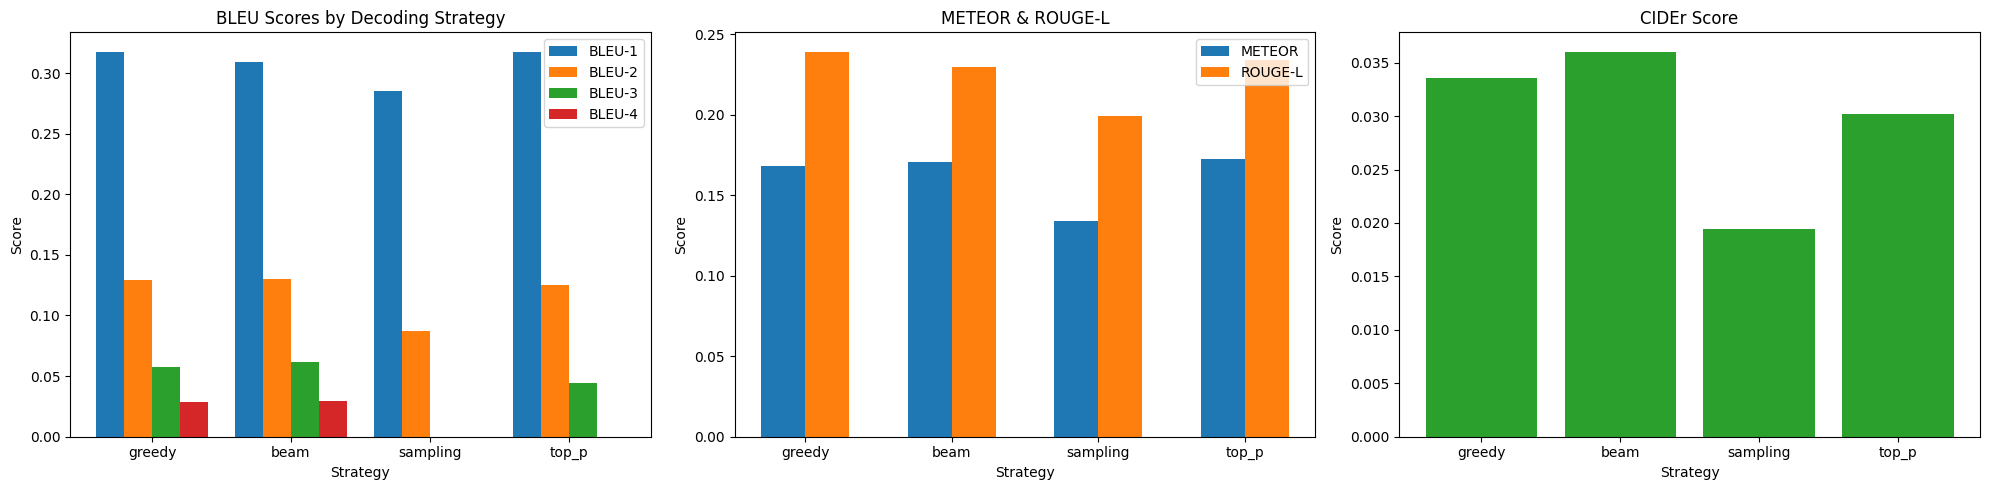

Saved metrics_by_strategy.png


In [29]:
# ── Plot: Decoding Strategy Metrics ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# BLEU scores
bleu_keys = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
x = np.arange(len(strategies))
width = 0.2
for i, bk in enumerate(bleu_keys):
    vals = [decoding_results[s][bk] for s in strategies]
    axes[0].bar(x + i * width, vals, width, label=bk)
axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels(strategies)
axes[0].set_title('BLEU Scores by Decoding Strategy')
axes[0].set_xlabel('Strategy')
axes[0].set_ylabel('Score')
axes[0].legend()

# METEOR & ROUGE-L
meteor_vals = [decoding_results[s]['METEOR'] for s in strategies]
rouge_vals = [decoding_results[s]['ROUGE-L'] for s in strategies]
x2 = np.arange(len(strategies))
axes[1].bar(x2 - 0.15, meteor_vals, 0.3, label='METEOR', color='tab:blue')
axes[1].bar(x2 + 0.15, rouge_vals, 0.3, label='ROUGE-L', color='tab:orange')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(strategies)
axes[1].set_title('METEOR & ROUGE-L')
axes[1].set_xlabel('Strategy')
axes[1].set_ylabel('Score')
axes[1].legend()

# CIDEr
cider_vals = [decoding_results[s]['CIDEr'] for s in strategies]
axes[2].bar(strategies, cider_vals, color='tab:green')
axes[2].set_title('CIDEr Score')
axes[2].set_xlabel('Strategy')
axes[2].set_ylabel('Score')

plt.tight_layout()
plt.savefig('metrics_by_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved metrics_by_strategy.png')

## 9 — Temperature Sensitivity Analysis

In [30]:
# ── Temperature sensitivity ──
temperatures = [0.3, 0.5, 0.7, 1.0, 1.3, 1.5]
temp_results = {}

for temp in temperatures:
    print(f'\nTemperature = {temp}')
    caps = generate_captions(model, processor, eval_samples,
                             strategy='top_p', temperature=temp, top_p=0.9)
    scores = compute_metrics(caps, references)
    temp_results[str(temp)] = scores
    print(f'  BLEU-4: {scores["BLEU-4"]:.4f} | METEOR: {scores["METEOR"]:.4f} | '
          f'CIDEr: {scores["CIDEr"]:.4f}')

print('\nTemperature sensitivity analysis complete.')


Temperature = 0.3


Generating (top_p):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 422, 'reflen': 452, 'guess': [422, 372, 322, 272], 'correct': [135, 17, 3, 1]}
ratio: 0.9336283185820052
  BLEU-4: 0.0248 | METEOR: 0.1612 | CIDEr: 0.0283

Temperature = 0.5


Generating (top_p):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 436, 'reflen': 464, 'guess': [436, 386, 336, 286], 'correct': [150, 29, 7, 2]}
ratio: 0.939655172411768
  BLEU-4: 0.0413 | METEOR: 0.1621 | CIDEr: 0.0424

Temperature = 0.7


...

{'testlen': 447, 'reflen': 468, 'guess': [447, 397, 347, 297], 'correct': [128, 15, 3, 1]}
ratio: 0.9551282051261643
  BLEU-4: 0.0226 | METEOR: 0.1337 | CIDEr: 0.0262

Temperature = 1.3


Generating (top_p):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 476, 'reflen': 485, 'guess': [476, 426, 376, 326], 'correct': [106, 15, 1, 0]}
ratio: 0.9814432989670486
  BLEU-4: 0.0000 | METEOR: 0.1169 | CIDEr: 0.0225

Temperature = 1.5


Generating (top_p):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 819, 'reflen': 570, 'guess': [819, 769, 719, 669], 'correct': [97, 10, 1, 0]}
ratio: 1.436842105260637
  BLEU-4: 0.0000 | METEOR: 0.1048 | CIDEr: 0.0220

Temperature sensitivity analysis complete.


In [31]:
# ── Save temperature CSV ──
temp_rows = []
for t, scores in temp_results.items():
    row = {'Temperature': float(t)}
    row.update(scores)
    temp_rows.append(row)

df_temp = pd.DataFrame(temp_rows)
df_temp.to_csv('temperature_sensitivity.csv', index=False)
print('Saved temperature_sensitivity.csv')
df_temp

Saved temperature_sensitivity.csv


,Temperature,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-L,CIDEr,METEOR
0,0.3,0.297953,0.112613,0.047921,0.024776,0.232283,0.028344,0.161217
1,0.5,0.322637,0.150771,0.076296,0.041311,0.227601,0.042427,0.162054
2,0.7,0.329535,0.149038,0.062526,0.029762,0.237725,0.035628,0.173893
3,1.0,0.273212,0.099243,0.043311,0.022603,0.195648,0.026165,0.133730
4,1.3,0.218518,0.086892,0.027010,0.000003,0.172589,0.022452,0.116939
5,1.5,0.118437,0.039245,0.012891,0.000001,0.135881,0.021995,0.104755


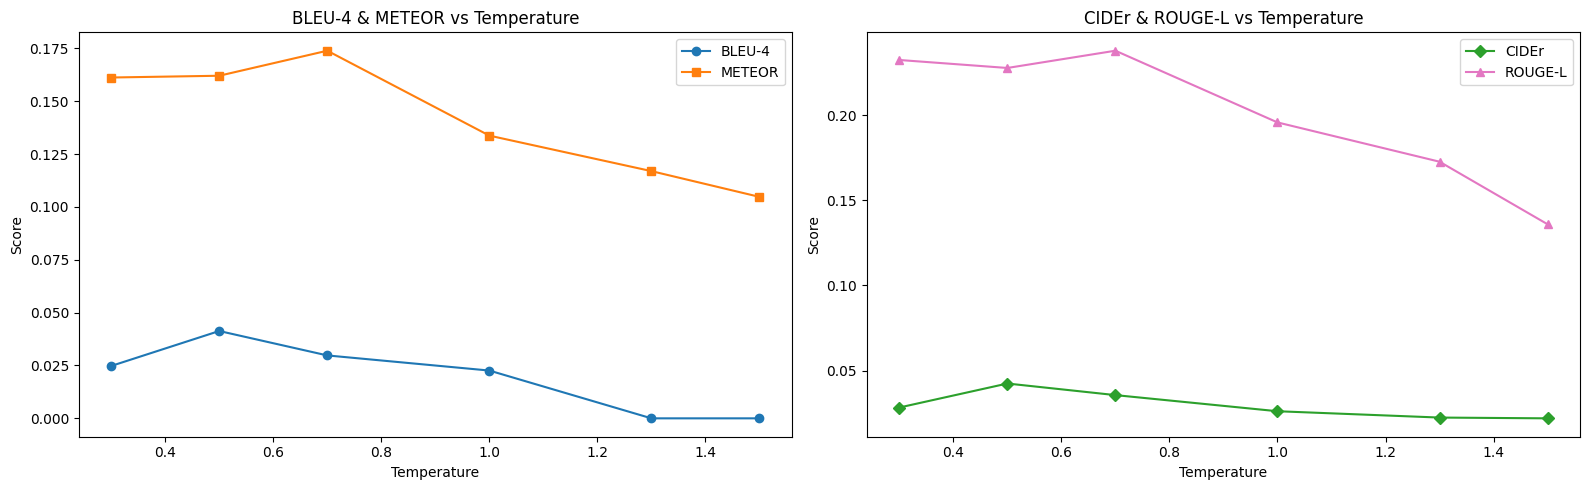

Saved temperature_sensitivity.png


In [32]:
# ── Plot: Temperature Sensitivity ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
temps = [float(t) for t in temp_results.keys()]

# BLEU-4 & METEOR
bleu4 = [temp_results[str(t)]['BLEU-4'] for t in temperatures]
meteor = [temp_results[str(t)]['METEOR'] for t in temperatures]
axes[0].plot(temps, bleu4, 'o-', label='BLEU-4', color='tab:blue')
axes[0].plot(temps, meteor, 's-', label='METEOR', color='tab:orange')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Score')
axes[0].set_title('BLEU-4 & METEOR vs Temperature')
axes[0].legend()

# CIDEr & ROUGE-L
cider = [temp_results[str(t)]['CIDEr'] for t in temperatures]
rouge = [temp_results[str(t)]['ROUGE-L'] for t in temperatures]
axes[1].plot(temps, cider, 'D-', label='CIDEr', color='tab:green')
axes[1].plot(temps, rouge, '^-', label='ROUGE-L', color='tab:pink')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Score')
axes[1].set_title('CIDEr & ROUGE-L vs Temperature')
axes[1].legend()

plt.tight_layout()
plt.savefig('temperature_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved temperature_sensitivity.png')

## 10 — Beam Width Sensitivity Analysis

In [33]:
# ── Beam width sensitivity ──
beam_widths = [1, 2, 3, 5, 8, 10]
beam_results = {}

for bw in beam_widths:
    print(f'\nBeam width = {bw}')
    caps = generate_captions(model, processor, eval_samples,
                             strategy='beam', beam_width=bw)
    scores = compute_metrics(caps, references)
    beam_results[str(bw)] = scores
    print(f'  BLEU-4: {scores["BLEU-4"]:.4f} | METEOR: {scores["METEOR"]:.4f} | '
          f'CIDEr: {scores["CIDEr"]:.4f}')

print('\nBeam width sensitivity analysis complete.')


Beam width = 1


Generating (beam):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 419, 'reflen': 452, 'guess': [419, 369, 319, 269], 'correct': [144, 21, 4, 1]}
ratio: 0.926991150440427
  BLEU-4: 0.0286 | METEOR: 0.1683 | CIDEr: 0.0336

Beam width = 2


Generating (beam):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 427, 'reflen': 455, 'guess': [427, 377, 327, 277], 'correct': [138, 21, 4, 1]}
ratio: 0.9384615384594759
  BLEU-4: 0.0280 | METEOR: 0.1694 | CIDEr: 0.0297

Beam width = 3


...

{'testlen': 461, 'reflen': 469, 'guess': [461, 411, 361, 311], 'correct': [145, 23, 5, 1]}
ratio: 0.982942430701529
  BLEU-4: 0.0292 | METEOR: 0.1707 | CIDEr: 0.0360

Beam width = 8


Generating (beam):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 459, 'reflen': 469, 'guess': [459, 409, 359, 309], 'correct': [152, 25, 6, 2]}
ratio: 0.9786780383774442
  BLEU-4: 0.0376 | METEOR: 0.1814 | CIDEr: 0.0333

Beam width = 10


Generating (beam):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 460, 'reflen': 468, 'guess': [460, 410, 360, 310], 'correct': [147, 24, 6, 2]}
ratio: 0.9829059829038826
  BLEU-4: 0.0370 | METEOR: 0.1781 | CIDEr: 0.0332

Beam width sensitivity analysis complete.


In [34]:
# ── Save beam width CSV ──
beam_rows = []
for bw, scores in beam_results.items():
    row = {'Beam Width': int(bw)}
    row.update(scores)
    beam_rows.append(row)

df_beam = pd.DataFrame(beam_rows)
df_beam.to_csv('beam_width_sensitivity.csv', index=False)
print('Saved beam_width_sensitivity.csv')
df_beam

Saved beam_width_sensitivity.csv


,Beam Width,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-L,CIDEr,METEOR
0,1,0.317646,0.129261,0.057854,0.028560,0.239156,0.033594,0.168271
1,2,0.302672,0.125657,0.056555,0.027965,0.233107,0.029661,0.169374
2,3,0.304610,0.129592,0.051685,0.025779,0.227711,0.030601,0.173725
3,5,0.309122,0.130389,0.061395,0.029243,0.229421,0.036032,0.170720
4,8,0.324018,0.139207,0.068177,0.037638,0.239360,0.033313,0.181392
5,10,0.314056,0.134413,0.066639,0.037010,0.232816,0.033232,0.178084


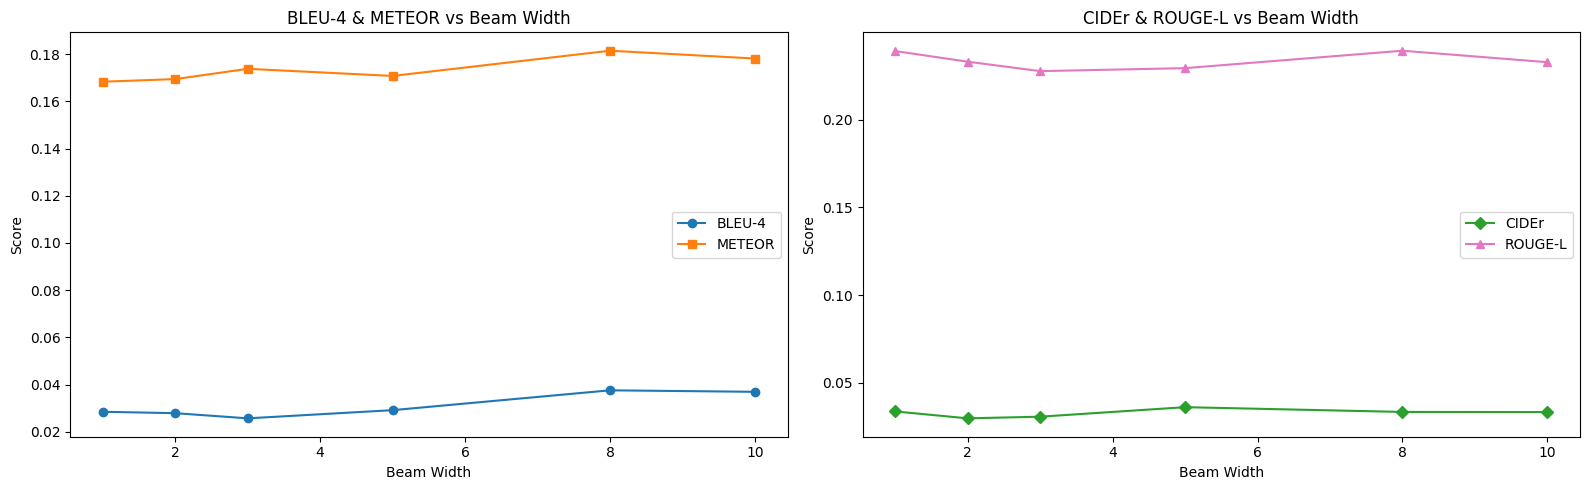

Saved beam_width_sensitivity.png


In [35]:
# ── Plot: Beam Width Sensitivity ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bws = [int(b) for b in beam_results.keys()]

# BLEU-4 & METEOR
bleu4 = [beam_results[str(b)]['BLEU-4'] for b in beam_widths]
meteor = [beam_results[str(b)]['METEOR'] for b in beam_widths]
axes[0].plot(bws, bleu4, 'o-', label='BLEU-4', color='tab:blue')
axes[0].plot(bws, meteor, 's-', label='METEOR', color='tab:orange')
axes[0].set_xlabel('Beam Width')
axes[0].set_ylabel('Score')
axes[0].set_title('BLEU-4 & METEOR vs Beam Width')
axes[0].legend()

# CIDEr & ROUGE-L
cider = [beam_results[str(b)]['CIDEr'] for b in beam_widths]
rouge = [beam_results[str(b)]['ROUGE-L'] for b in beam_widths]
axes[1].plot(bws, cider, 'D-', label='CIDEr', color='tab:green')
axes[1].plot(bws, rouge, '^-', label='ROUGE-L', color='tab:pink')
axes[1].set_xlabel('Beam Width')
axes[1].set_ylabel('Score')
axes[1].set_title('CIDEr & ROUGE-L vs Beam Width')
axes[1].legend()

plt.tight_layout()
plt.savefig('beam_width_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved beam_width_sensitivity.png')

## 11 — Fine-Tuning Comparison (Before vs After LoRA)

In [36]:
# ── Fine-tuning comparison: Baseline vs LoRA ──
# Baseline was computed earlier; now get LoRA-tuned scores with beam-5
lora_captions = generate_captions(model, processor, eval_samples,
                                   strategy='beam', beam_width=5)
lora_scores = compute_metrics(lora_captions, references)

finetuning_comparison = {
    'Baseline (no FT)': baseline_scores,
    'LoRA (10 epochs, cosine LR)': lora_scores,
}

print('\n=== Fine-Tuning Comparison ===')
for name, scores in finetuning_comparison.items():
    print(f'\n{name}:')
    for k, v in scores.items():
        print(f'  {k}: {v:.4f}')

Generating (beam):   0%|          | 0/50 [00:00<?, ?it/s]

{'testlen': 461, 'reflen': 469, 'guess': [461, 411, 361, 311], 'correct': [145, 23, 5, 1]}
ratio: 0.982942430701529

=== Fine-Tuning Comparison ===

Baseline (no FT):
  BLEU-1: 0.3172
  BLEU-2: 0.1393
  BLEU-3: 0.0677
  BLEU-4: 0.0313
  ROUGE-L: 0.2272
  CIDEr: 0.0422
  METEOR: 0.1769

LoRA (10 epochs, cosine LR):
  BLEU-1: 0.3091
  BLEU-2: 0.1304
  BLEU-3: 0.0614
  BLEU-4: 0.0292
  ROUGE-L: 0.2294
  CIDEr: 0.0360
  METEOR: 0.1707


In [37]:
# ── Save fine-tuning comparison CSV ──
ft_rows = []
for name, scores in finetuning_comparison.items():
    row = {'Strategy': name}
    row.update(scores)
    ft_rows.append(row)

df_ft = pd.DataFrame(ft_rows)
df_ft.to_csv('finetuning_comparison.csv', index=False)
print('Saved finetuning_comparison.csv')
df_ft

Saved finetuning_comparison.csv


,Strategy,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-L,CIDEr,METEOR
0,Baseline (no FT),0.317192,0.139251,0.067725,0.031296,0.227169,0.042167,0.176905
1,"LoRA (10 epochs, cosine LR)",0.309122,0.130389,0.061395,0.029243,0.229421,0.036032,0.170720


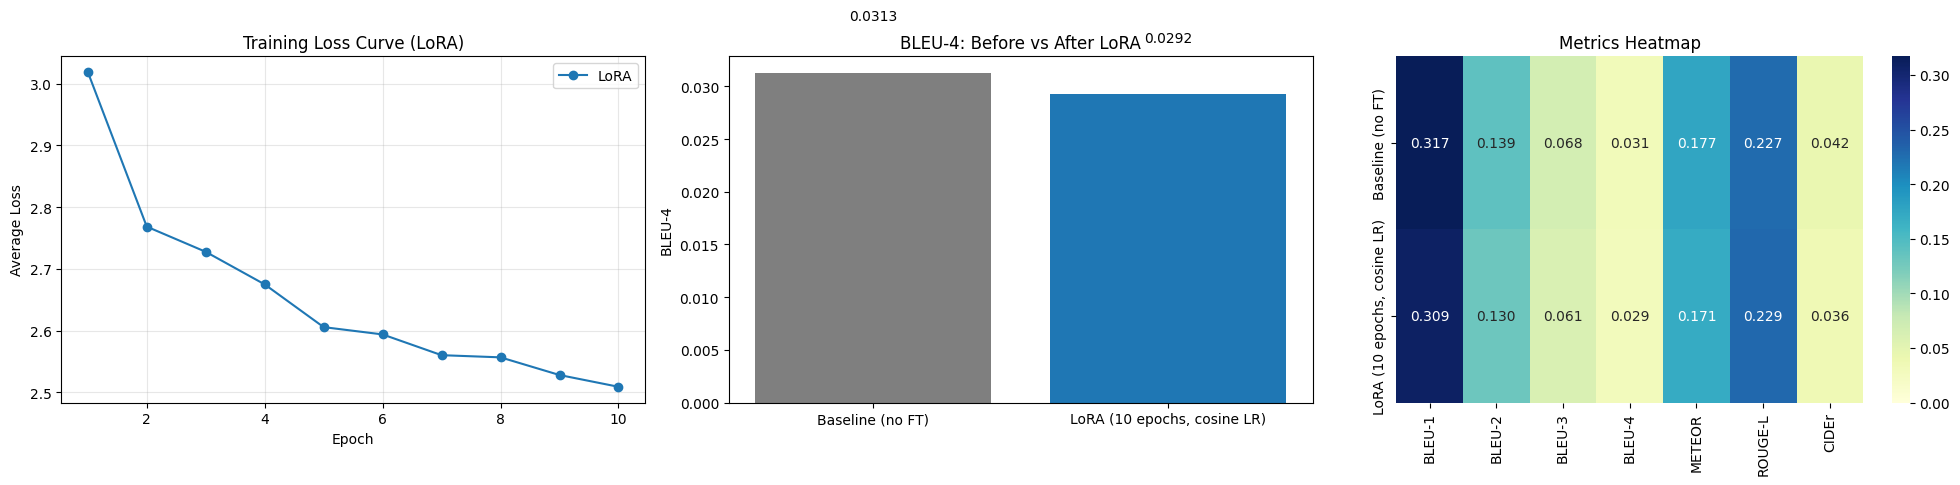

Saved finetuning_comparison.png


In [38]:
# ── Plot: Fine-tuning Comparison ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ft_names = list(finetuning_comparison.keys())
colors = ['tab:gray', 'tab:blue']

# Training loss curve
axes[0].plot(range(1, NUM_EPOCHS + 1), training_losses, 'o-', color='tab:blue',
             label='LoRA')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average Loss')
axes[0].set_title('Training Loss Curve (LoRA)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BLEU-4 comparison
bleu4_vals = [finetuning_comparison[n]['BLEU-4'] for n in ft_names]
axes[1].bar(ft_names, bleu4_vals, color=colors)
axes[1].set_title('BLEU-4: Before vs After LoRA')
axes[1].set_ylabel('BLEU-4')
for i, v in enumerate(bleu4_vals):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

# Heatmap
metrics_keys = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'CIDEr']
heatmap_data = []
for name in ft_names:
    heatmap_data.append([finetuning_comparison[name][m] for m in metrics_keys])

df_heatmap = pd.DataFrame(heatmap_data, index=ft_names, columns=metrics_keys)
sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap='YlGnBu',
            ax=axes[2], vmin=0)
axes[2].set_title('Metrics Heatmap')

plt.tight_layout()
plt.savefig('finetuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved finetuning_comparison.png')

## 12 — Performance Scores Summary

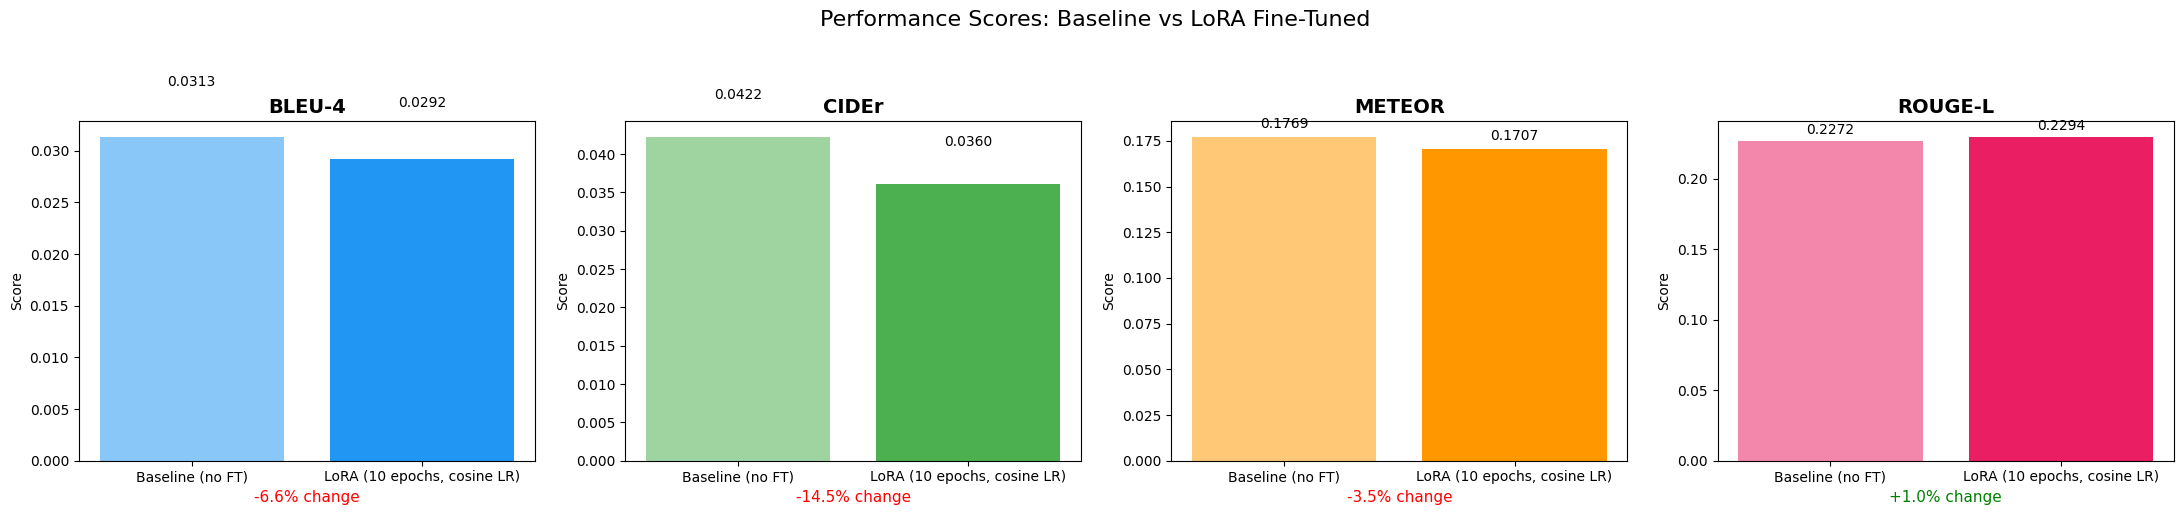

Saved performance_scores.png


In [39]:
# ── Performance scores bar chart (BLEU-4, CIDEr, METEOR, ROUGE-L) ──
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

focus_metrics = ['BLEU-4', 'CIDEr', 'METEOR', 'ROUGE-L']
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

# Compare baseline vs LoRA for each metric
for idx, (metric, color) in enumerate(zip(focus_metrics, bar_colors)):
    vals = [finetuning_comparison[n][metric] for n in ft_names]
    bars = axes[idx].bar(ft_names, vals, color=[f'{color}88', color])
    axes[idx].set_title(f'{metric}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Score')
    for i, v in enumerate(vals):
        axes[idx].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

    # Show improvement
    if len(vals) == 2 and vals[0] > 0:
        pct = ((vals[1] - vals[0]) / vals[0]) * 100
        sign = '+' if pct > 0 else ''
        axes[idx].set_xlabel(f'{sign}{pct:.1f}% change', fontsize=11, color='green' if pct > 0 else 'red')

plt.suptitle('Performance Scores: Baseline vs LoRA Fine-Tuned', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('performance_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved performance_scores.png')

## 13 — Complete Summary Heatmap

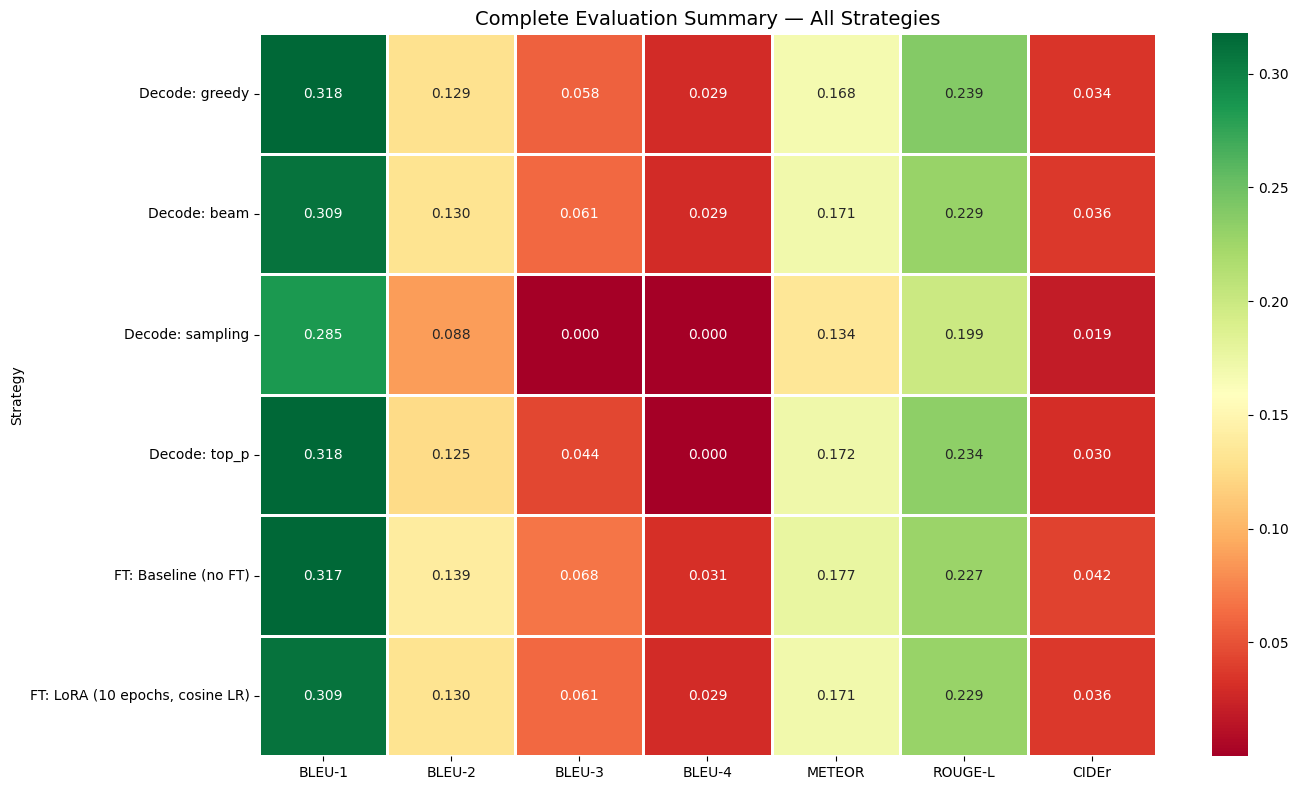

Saved complete_summary_heatmap.png


In [40]:
# ── Complete summary heatmap (all strategies) ──
all_strategies = {}

# Decoding strategies
for strat, scores in decoding_results.items():
    all_strategies[f'Decode: {strat}'] = scores

# Fine-tuning comparison
for name, scores in finetuning_comparison.items():
    all_strategies[f'FT: {name}'] = scores

metrics_keys = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'CIDEr']
heatmap_data = []
row_labels = []
for name, scores in all_strategies.items():
    heatmap_data.append([scores[m] for m in metrics_keys])
    row_labels.append(name)

df_summary = pd.DataFrame(heatmap_data, index=row_labels, columns=metrics_keys)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(df_summary, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax, linewidths=1, linecolor='white')
ax.set_title('Complete Evaluation Summary — All Strategies', fontsize=14)
ax.set_ylabel('Strategy')

plt.tight_layout()
plt.savefig('complete_summary_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved complete_summary_heatmap.png')

## 14 — Qualitative Gallery

In [41]:
# ── Qualitative gallery: show 5 images with captions ──
gallery_indices = list(range(min(5, len(eval_samples))))

fig, axes = plt.subplots(len(gallery_indices), 1, figsize=(8, 6 * len(gallery_indices)))
if len(gallery_indices) == 1:
    axes = [axes]

# Generate captions for gallery with best config (beam-5)
gallery_captions_greedy = generate_captions(
    model, processor,
    [eval_samples[i] for i in gallery_indices],
    strategy='greedy'
)
gallery_captions_beam = generate_captions(
    model, processor,
    [eval_samples[i] for i in gallery_indices],
    strategy='beam', beam_width=5
)
gallery_captions_topp = generate_captions(
    model, processor,
    [eval_samples[i] for i in gallery_indices],
    strategy='top_p', temperature=0.7
)

for j, idx in enumerate(gallery_indices):
    sample = eval_samples[idx]
    img = load_image(sample)
    ref = references[idx][0] if references[idx] else 'N/A'

    axes[j].imshow(img)
    axes[j].axis('off')
    axes[j].set_title(
        f'Reference: {ref}\n'
        f'Greedy: {gallery_captions_greedy[j]}\n'
        f'Beam-5: {gallery_captions_beam[j]}\n'
        f'Top-p (T=0.7): {gallery_captions_topp[j]}',
        fontsize=10, loc='left', wrap=True
    )

plt.tight_layout()
plt.savefig('qualitative_gallery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved qualitative_gallery.png')

Output hidden; open in https://colab.research.google.com to view.

## 15 — Save All Results to JSON

In [42]:
# ── Compile all results into a single JSON ──
all_results = {
    'model_config': {
        'base_model': MODEL_NAME,
        'fine_tuning': 'LoRA',
        'lora_r': 16,
        'lora_alpha': 32,
        'epochs': NUM_EPOCHS,
        'batch_size': 8,
        'learning_rate': LEARNING_RATE,
        'scheduler': 'CosineAnnealingLR',
        'train_size': TRAIN_SIZE,
    },
    'training_losses': training_losses,
    'decoding_strategy_metrics': decoding_results,
    'temperature_sensitivity': temp_results,
    'beam_width_sensitivity': beam_results,
    'finetuning_comparison': finetuning_comparison,
    'sample_captions': sample_captions_all,
}

with open('milestone4_final_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('Saved milestone4_final_results.json')
print('\n=== All outputs saved ===')
print('CSVs:  decoding_metrics.csv, temperature_sensitivity.csv, beam_width_sensitivity.csv, finetuning_comparison.csv')
print('Plots: metrics_by_strategy.png, temperature_sensitivity.png, beam_width_sensitivity.png,')
print('       finetuning_comparison.png, performance_scores.png, complete_summary_heatmap.png, qualitative_gallery.png')
print('JSON:  milestone4_final_results.json')


Saved milestone4_final_results.json

=== All outputs saved ===
CSVs:  decoding_metrics.csv, temperature_sensitivity.csv, beam_width_sensitivity.csv, finetuning_comparison.csv
Plots: metrics_by_strategy.png, temperature_sensitivity.png, beam_width_sensitivity.png,
       finetuning_comparison.png, performance_scores.png, complete_summary_heatmap.png, qualitative_gallery.png
JSON:  milestone4_final_results.json


In [43]:
# ── Save LoRA-tuned BLIP-2 model ──
SAVE_DIR = '/content/drive/MyDrive/NEU/IE 7615 Deep Learning/Generative Project/Milestone 4/blip2-opt-2.7b-lora'

model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

print(f'Model and processor saved to {SAVE_DIR}')

Model and processor saved to /content/drive/MyDrive/NEU/IE 7615 Deep Learning/Generative Project/Milestone 4/blip2-opt-2.7b-lora
